# Predicting European Wheat Futures Returns from Satellite-Derived Agricultural Data: A Test of Market Efficiency

**MA429 — Algorithms in Machine Learning**

---

## Abstract

We investigate whether publicly available satellite-derived agricultural data from the CY-Bench benchmark (Paudel et al., 2025) predicts Euronext Milling Wheat N2 futures returns. Following the practical methodology prescribed by Goodfellow, Bengio, and Courville (2016, Chapter 11), we systematically establish performance metrics, build default baselines, diagnose underfitting versus overfitting through train-test gap analysis, augment the feature space with cross-commodity market data, tune hyperparameters via random search (Bergstra and Bengio, 2012), and escalate model complexity from linear baselines through tree ensembles to deep feedforward neural networks. We compare two spatial aggregation strategies — agro-climatic clustering and per-region modelling — and evaluate both standard return prediction and tail event detection.

All models produce negative out-of-sample R-squared for standard return prediction, consistent with the semi-strong Efficient Market Hypothesis (Fama, 1970). However, when the task is reformulated as tail event detection, the gate classifier achieves AUC significantly above chance, with agricultural features outperforming market-only features. Directional accuracy increases monotonically with event severity, reaching 60% for three-sigma events. Deep neural networks with dropout and batch normalisation do not outperform regularised tree ensembles on this tabular dataset, consistent with the findings of Grinsztajn, Oyallon, and Varoquaux (2022) that tree-based methods remain competitive on medium-sized tabular data.

**Keywords:** market efficiency, wheat futures, satellite data, CY-Bench, tail risk, machine learning, neural networks, walk-forward validation

---

## 1. Methodological Framework

This notebook implements the practical design process prescribed by Goodfellow, Bengio, and Courville (2016, Chapter 11, pp. 416-425). The methodology consists of four iterative steps that we apply sequentially, documenting each diagnostic decision.

The first step concerns **performance metrics** (§11.1). Goodfellow et al. write that "determining your goals, in terms of which error metric to use, is a necessary first step because your error metric will guide all your future actions" (p. 417). For rare-event detection, they warn that accuracy can be trivially maximised and recommend precision-recall or AUC instead (p. 418). We define separate metric suites for standard return prediction and tail event detection.

The second step establishes **default baseline models** (§11.2). The chapter advises beginning simply: "if your problem has a chance of being solved by just choosing a few linear weights correctly, you may want to begin with a simple statistical model" (p. 420). Model family should follow data structure — feedforward networks for fixed-size vectors, convolutional for spatial topology, recurrent for sequences (p. 420). We begin with Ridge regression and escalate through tree ensembles to deep feedforward networks with ReLU activations, batch normalisation, dropout, and early stopping — all defaults recommended by Goodfellow et al. (p. 420).

The third step asks **whether to gather more data** (§11.3). The diagnostic sequence is: check training error first — if high, increase capacity; if training is good but test is poor, regularise or gather more data; if both are poor despite large capacity, "the problem might be the quality of the training data" (p. 421). This diagnostic drives our decision to (a) augment features with market data and (b) reformulate the task as tail event detection.

The fourth step addresses **hyperparameter selection** (§11.4). Goodfellow et al. note that "the learning rate is perhaps the most important hyperparameter" (p. 424) and recommend understanding the U-shaped relationship between capacity and generalisation error. Following Bergstra and Bengio (2012), we use random search over hyperparameter distributions.

---

## 2. Performance Metrics (Goodfellow et al. §11.1)

### 2.1 The Bayes Error for Financial Returns

Goodfellow et al. observe that "the Bayes error defines the minimum error rate that you can hope to achieve, even if you have infinite training data" (p. 417). For daily wheat futures returns, the Bayes error is extremely high because returns are dominated by unpredictable noise. Gu, Kelly, and Xiu (2020) found monthly out-of-sample R-squared of only 0.4% even with 94 stock characteristics and panel data spanning thousands of firms — our single-asset task is strictly harder.

### 2.2 Standard Return Prediction Metrics

We report out-of-sample R-squared ($R^2_{OOS} = 1 - SS_{res}/SS_{tot}$), directional accuracy, and RMSE. Negative R-squared indicates the model underperforms the unconditional mean — a diagnostic signal, not a failure. We also report **training R-squared** to diagnose underfitting versus overfitting per Goodfellow §11.3.

### 2.3 Tail Event Detection Metrics

Goodfellow et al. address rare events: "suppose that only one in every million people has this disease. We can easily achieve 99.9999 percent accuracy... Clearly, accuracy is a poor way to characterize the performance of such a system" (p. 418). Our tail events occur on ~5% of days. We use Gate AUC (Fawcett, 2006), conditional directional accuracy on tail days (the tradeable metric), and separation ratio. We omit R-squared for the filtered target because 95% of values are zero.

---

## 3. Data

### 3.1 Price Data and Agricultural Features

We use Euronext Milling Wheat N2 roll-adjusted daily prices (2003-2023, 5,389 trading days) and CY-Bench sub-national agricultural indicators for 515 regions across France (97), Germany (401), and Poland (17). Features include weather (AgERA5), soil moisture (GLDAS), vegetation indices (MODIS NDVI, JRC fPAR), engineered into 76 features per region capturing rolling means, growing degree days, drought indices, NDVI anomalies, and crop-phase stress indicators.

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "./cy-bench/CA1 Commodity Historical Data v2.xlsx"
CYBENCH_DATA_DIR = "../data/raw/cybench/cybench-data/wheat/"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return
AG_LAG_DAYS = 0        # No artificial lag: futures traders react in real time

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_excel(FUTURES_PATH, na_values=['#N/A N/A', '#N/A', 'N/A'])
futures_raw = futures_raw.drop(columns=[c for c in futures_raw.columns 
                                         if 'Unnamed' in str(c) or 'Setting' in str(c)],
                                errors='ignore')
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6968, 16)


,Date,PX_LAST,PX_BID,OPEN_INT,PX_OPEN,PX_HIGH,PX_LOW,PX_VOLUME,PX_LAST_ADJ,PX_BID_ADJ,OPEN_INT_ADJ,PX_OPEN_ADJ,PX_HIGH_ADJ,PX_LOW_ADJ,PX_VOLUME_ADJ,ROLL
0,2026-03-02,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,201.25,201.00,NaN,203.75,204.25,200.50,85071.0,1.001244
1,2026-02-27,197.50,193.75,9694.0,193.50,197.75,193.50,12930.0,201.50,197.67,9694.0,197.42,201.76,197.42,12930.0,0.999140
2,2026-02-26,193.25,192.00,15198.0,193.25,194.50,192.25,12908.0,197.16,195.89,15198.0,197.16,198.44,196.14,12908.0,0.986523
3,2026-02-25,193.00,192.50,19460.0,195.50,195.75,192.50,15145.0,196.91,196.40,19460.0,199.46,199.71,196.40,15145.0,0.982688
4,2026-02-24,195.25,195.00,25540.0,195.50,197.25,195.00,20632.0,199.20,198.95,25540.0,199.46,201.24,198.95,20632.0,0.981402


In [3]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

# Use adjusted columns
futures['Price'] = futures['PX_LAST_ADJ']
futures['Open'] = futures['PX_OPEN_ADJ']
futures['High'] = futures['PX_HIGH_ADJ']
futures['Low'] = futures['PX_LOW_ADJ']
futures['Volume'] = futures['PX_VOLUME_ADJ']

# Filter to 2003-2023
futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5389 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume
0,2002-12-31,76.15,76.15,76.15,76.15,2.0
1,2003-01-02,76.15,76.15,76.15,76.15,38.0
2,2003-01-03,76.15,76.15,76.15,76.15,4.0
3,2003-01-06,76.15,76.15,76.15,76.15,5.0
4,2003-01-07,75.31,75.98,75.98,75.31,97.0


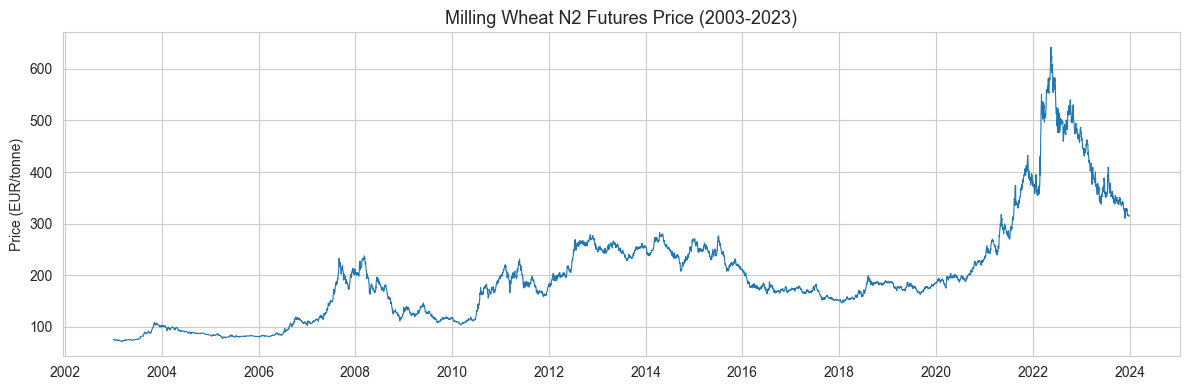

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat N2 Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


In [6]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# DK not included because yield data starts in 2006
# countries = ['FR', 'DE', 'PL', 'RO', 'BG', 'LT', 'CZ', 'ES']
# countries = ['FR', 'DE', 'PL', 'RO', 'BG']
countries = ['FR', 'DE', 'PL']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from ../data/raw/cybench/cybench-data/wheat/FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

  DE: Loading from ../data/raw/cybench/cybench-data/wheat/DE
    meteo: (3368400, 11), 401 regions
    soil_moisture: (3055200, 5), 400 regions
    ndvi: (350540, 4), 401 regions
    fpar: (332028, 4), 401 regions
    yield: (15233, 12), 397 regions

  PL: Loading from ../data/raw/cybench/cybench-data/wheat/PL
    meteo: (142800, 11), 17 regions
    soil_moisture: (129846, 5), 17 regions
    ndvi: (16115, 4), 17 regions
    fpar: (14076, 4), 17 regions
    yield: (301, 7), 17 regions

Countries loaded: ['FR', 'DE', 'PL']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  DE: 401 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  PL: 17 unique re

The following cells execute the computationally expensive data loading, production weight calculation, and feature engineering pipeline. Outputs are preserved from previous execution.

In [7]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights
  DE: Filled 15223 missing production values (yield * forward-filled harvest_area)
  DE: 10 rows still missing production (no area data available)
  DE: 396 regions with production weights
  PL: 17 regions with production weights

Total regions with production weights: 508
  FR: 95 regions, years 1989-2020
  DE: 396 regions, years 1979-2021
  PL: 17 regions, years 2003-2020


In [8]:
# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

Building per-region daily datasets...

  FR: 97 regions processed
    Sample region FR102: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  DE: 401 regions processed
    Sample region DE111: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  PL: 17 regions processed
    Sample region PL21: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31

Total regions across all countries: 515


In [9]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 515 total regions in 'region_daily_data/'
After filtering to ['FR', 'DE', 'PL']: 515 regions
Loaded 515 regions
countries: {'DE': 401, 'FR': 97, 'PL': 17}


In [10]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # ============================================================
    # A. PHENOLOGICAL PHASE INDICATORS
    # Binary flags for which crop phase we're in.
    # French winter wheat phenology:
    #   Sowing → Emergence: Oct-Nov
    #   Dormancy / Vernalisation: Dec-Feb
    #   Stem elongation: Mar-Apr
    #   Heading / Flowering: May
    #   Grain filling: Jun-Jul
    # ============================================================
    df['in_growing_season'] = ((month >= 10) | (month <= 7)).astype(float)
    df['phase_dormant'] = ((month >= 12) | (month <= 2)).astype(float)
    df['phase_stem_elong'] = ((month >= 3) & (month <= 4)).astype(float)
    df['phase_flowering'] = (month == 5).astype(float)
    df['phase_grain_fill'] = ((month >= 6) & (month <= 7)).astype(float)

    # ============================================================
    # B. PHASE-CONDITIONAL STRESS FEATURES
    # These only accumulate stress during vulnerable windows.
    # ============================================================

    # --- Vernalisation frost stress (Dec-Feb): days < -10°C ---
    if 'meteo_tmin' in df.columns:
        frost_mask = df['phase_dormant'] * (df['meteo_tmin'] < -10).astype(float)
        df['winterkill_risk_30d'] = frost_mask.rolling(30, min_periods=5).sum()
        df['winterkill_risk_60d'] = frost_mask.rolling(60, min_periods=5).sum()
        # Milder frost days (< -5°C) during dormancy
        mild_frost = df['phase_dormant'] * (df['meteo_tmin'] < -5).astype(float)
        df['frost_days_dormant_60d'] = mild_frost.rolling(60, min_periods=5).sum()

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # --- Flowering drought (Apr-Jun): cumul water deficit ---
    if 'meteo_cwb' in df.columns:
        flower_cwb = df['meteo_cwb'].copy()
        flower_cwb[~((month >= 4) & (month <= 6))] = 0
        df['flowering_drought_60d'] = flower_cwb.rolling(60, min_periods=5).sum()
        df['flowering_drought_90d'] = flower_cwb.rolling(90, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'ndvi_ndvi' in df.columns:
        df['doy'] = df.index.dayofyear
        ndvi_clim = df.groupby('doy')['ndvi_ndvi'].expanding().mean()
        ndvi_clim = ndvi_clim.reset_index(level=0, drop=True).sort_index()
        df['ndvi_anomaly'] = df['ndvi_ndvi'] - ndvi_clim
        df['ndvi_anomaly_30d'] = df['ndvi_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['doy'])

    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # D. COMPACT ROLLING FEATURES
    # 30 and 60-day windows on key variables.
    # CY-Bench (Paudel et al. 2025, §2.2.3): "monthly averages of
    # tmin, tmax, tavg, prec, cumulative CWB... cumulative GDD,
    # cumulative precipitation, cumulative fPAR, cumulative NDVI"
    # ============================================================
    key_vars = [v for v in ['meteo_tavg', 'meteo_tmin', 'meteo_tmax',
                            'meteo_prec', 'meteo_vpd', 'meteo_cwb',
                            'soil_moisture_ssm', 'ndvi_ndvi', 'fpar_fpar']
                if v in df.columns]
    for window in [30, 60]:
        for var in key_vars:
            df[f'{var}_mean_{window}d'] = df[var].rolling(window, min_periods=10).mean()

    # Cumulative precipitation
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            df[f'cumul_prec_{window}d'] = df['meteo_prec'].rolling(window, min_periods=10).sum()

    # Growing degree days (base 0°C)
    if 'meteo_tavg' in df.columns:
        gdd_daily = df['meteo_tavg'].clip(lower=0)
        for window in [30, 60]:
            df[f'gdd_cumul_{window}d'] = gdd_daily.rolling(window, min_periods=10).sum()

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # G. DIURNAL TEMPERATURE RANGE (DTR)
    # Large DTR indicates clear skies (drought risk); small DTR
    # indicates cloud cover (rain). Used in crop-climate studies.
    # (Lobell, 2007; Laudien et al., 2023)
    # ============================================================
    if 'meteo_tmax' in df.columns and 'meteo_tmin' in df.columns:
        df['dtr'] = df['meteo_tmax'] - df['meteo_tmin']
        df['dtr_mean_30d'] = df['dtr'].rolling(30, min_periods=10).mean()
        df['dtr_anomaly_30d'] = df['dtr'] - df['dtr'].expanding(min_periods=60).mean()

    # ============================================================
    # H. VPD-BASED DROUGHT STRESS INDEX
    # Vapour pressure deficit is a stronger predictor of crop
    # stress than temperature alone. High VPD = plant stomata
    # close = photosynthesis stops = yield loss.
    # (Lobell et al., 2014; Schlenker & Roberts, 2009)
    # ============================================================
    if 'meteo_vpd' in df.columns:
        vpd_critical = df['meteo_vpd'].copy()
        vpd_critical[~((month >= 3) & (month <= 7))] = 0
        df['vpd_stress_critical_30d'] = vpd_critical.rolling(30, min_periods=5).mean()
        df['vpd_stress_critical_60d'] = vpd_critical.rolling(60, min_periods=5).mean()
        # Days with VPD > 15 hPa (high atmospheric demand)
        df['high_vpd_days_30d'] = (df['meteo_vpd'] > 15).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # I. SOIL MOISTURE DEFICIT INDEX (SMDI-like)
    # Z-score of soil moisture relative to expanding climatology.
    # Negative = drier than normal.
    # (Narasimhan & Srinivasan, 2005)
    # ============================================================
    for sm_var in ['soil_moisture_ssm', 'soil_moisture_rsm']:
        if sm_var in df.columns:
            sm_mean = df[sm_var].expanding(min_periods=60).mean()
            sm_std = df[sm_var].expanding(min_periods=60).std()
            df[f'{sm_var}_zscore'] = (df[sm_var] - sm_mean) / sm_std.replace(0, np.nan)
            df[f'{sm_var}_zscore_30d'] = df[f'{sm_var}_zscore'].rolling(30, min_periods=5).mean()

    # ============================================================
    # J. RADIATION USE EFFICIENCY PROXY
    # FPAR * radiation ≈ absorbed photosynthetically active
    # radiation (APAR). Proxy for biomass accumulation rate.
    # (Monteith, 1972; widely used in crop models)
    # ============================================================
    if 'fpar_fpar' in df.columns and 'meteo_rad' in df.columns:
        df['apar_proxy'] = df['fpar_fpar'] * df['meteo_rad']
        df['apar_proxy_mean_30d'] = df['apar_proxy'].rolling(30, min_periods=10).mean()
        df['apar_doy'] = df.index.dayofyear
        apar_clim = df.groupby('apar_doy')['apar_proxy'].expanding().mean()
        apar_clim = apar_clim.reset_index(level=0, drop=True).sort_index()
        df['apar_anomaly'] = df['apar_proxy'] - apar_clim
        df = df.drop(columns=['apar_doy'])

    # ============================================================
    # K. TEMPERATURE OPTIMALITY INDEX
    # Wheat grows optimally at 15-22°C. We measure how far
    # current conditions deviate from this optimum.
    # (Porter & Gawith, 1999)
    # ============================================================
    if 'meteo_tavg' in df.columns:
        opt_low, opt_high = 15, 22
        temp = df['meteo_tavg']
        df['temp_suboptimal'] = np.where(
            temp < opt_low, opt_low - temp,
            np.where(temp > opt_high, temp - opt_high, 0)
        )
        df['temp_suboptimal_30d'] = df['temp_suboptimal'].rolling(30, min_periods=10).mean()
        # During critical phases only (Mar-Jul)
        subopt_critical = df['temp_suboptimal'].copy()
        subopt_critical[~((month >= 3) & (month <= 7))] = 0
        df['temp_suboptimal_critical_60d'] = subopt_critical.rolling(60, min_periods=10).mean()

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features — they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions...\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 515 regions
  Before: ~12 features per region
  After:  ~76 features per region (+64 engineered)


---

## 4. Spatial Aggregation: Clustering vs. Per-Region Models (Goodfellow et al. §11.2)

### 4.1 The Dimensionality Problem

With 515 regions and 76 features per region, the raw feature matrix contains 39,140 columns — far exceeding the 5,364 observations. Goodfellow et al. (§11.2) advise choosing model complexity relative to data size: "unless your training set contains tens of millions of examples or more, you should include some mild forms of regularization from the start" (p. 420).

We implement two approaches to this problem. The first approach (Approach A) clusters regions into agro-climatic zones and aggregates features within each cluster, producing a wide matrix of ~450 features. The second approach (Approach B) fits a separate lightweight model per region and aggregates the 515 predictions using production weights. Paudel et al. (2022) demonstrated that regional models outperform nationally aggregated models for crop yield prediction, motivating this comparison.

### 4.2 Approach A: Agro-Climatic Clustering

Processing correlation matrices for 515 regions...
Total unique features found across all regions: 76


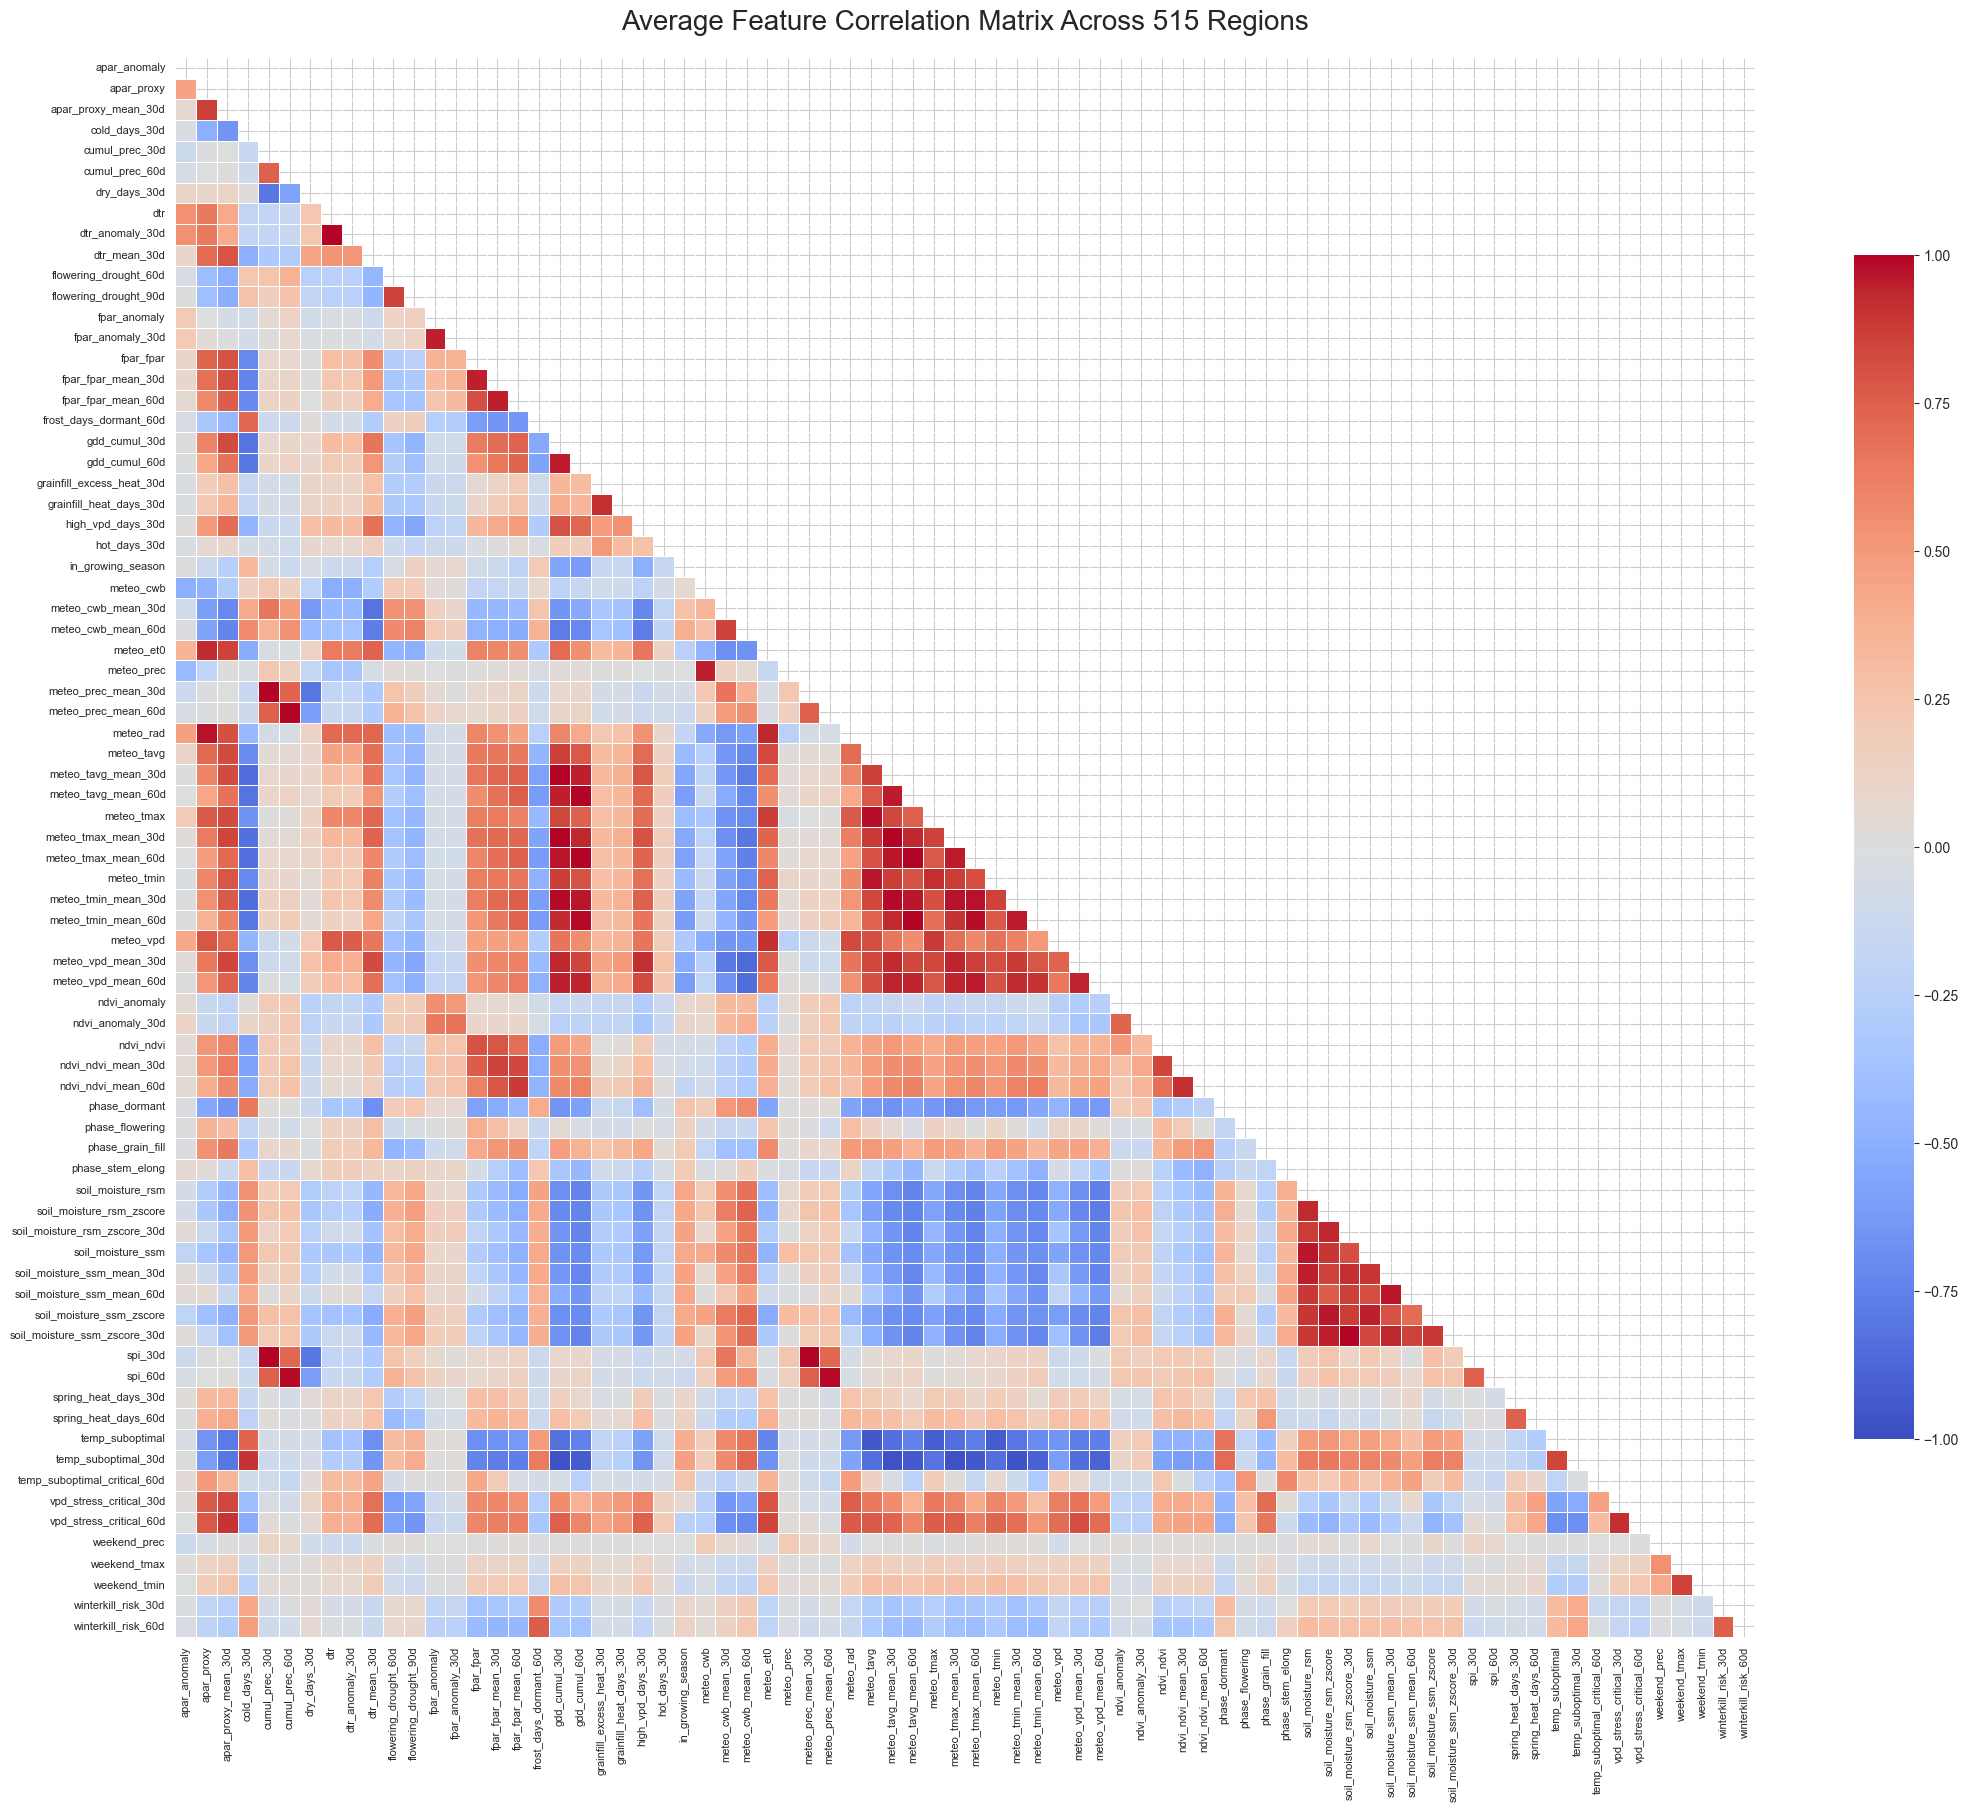

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_average_correlation(region_dfs_dict):
    """
    Computes an average correlation matrix across multiple regions,
    handling missing features dynamically via reindexing.
    """
    fisher_z_matrices = []
    
    print(f"Processing correlation matrices for {len(region_dfs_dict)} regions...")
    
    # ------------------------------------------------------------
    # FIX STEP 1: Find the master list of all unique features
    # ------------------------------------------------------------
    master_features = set()
    for df in region_dfs_dict.values():
        cols = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number]).columns
        master_features.update(cols)
        
    master_features = sorted(list(master_features))
    print(f"Total unique features found across all regions: {len(master_features)}")
    
    # ------------------------------------------------------------
    # FIX STEP 2: Standardize all matrices to the master shape
    # ------------------------------------------------------------
    for adm_id, df in region_dfs_dict.items():
        feat_df = df.drop(columns=['date'], errors='ignore').select_dtypes(include=[np.number])
        
        # Calculate raw correlation
        corr = feat_df.corr()
        
        # Force the matrix to be exactly the size of master_features
        # Missing columns/rows become NaN automatically
        corr = corr.reindex(index=master_features, columns=master_features)
        
        # Apply Fisher Z-transform
        corr_vals = corr.values
        # Clip values to avoid infinity from arctanh(1.0), keeping NaNs intact
        corr_clipped = np.where(np.isnan(corr_vals), np.nan, np.clip(corr_vals, -0.9999, 0.9999))
        fisher_z = np.arctanh(corr_clipped)
        
        fisher_z_matrices.append(fisher_z)

    # ------------------------------------------------------------
    # Calculate the mean and Inverse Fisher Transform
    # ------------------------------------------------------------
    # Suppress warnings if an entire slice is NaN (e.g., a feature with zero variance)
    with np.errstate(invalid='ignore'):
        avg_z_matrix = np.nanmean(fisher_z_matrices, axis=0)
    
    avg_corr_matrix = np.tanh(avg_z_matrix)
    
    # Return standard DataFrame
    avg_corr_df = pd.DataFrame(avg_corr_matrix, index=master_features, columns=master_features)
    
    return avg_corr_df

# ==========================================
# Execute the corrected function
# ==========================================
avg_correlation_matrix = compute_average_correlation(all_region_dfs)

# ==========================================
# Visualization: The Heatmap
# ==========================================
plt.figure(figsize=(22, 18))

mask = np.triu(np.ones_like(avg_correlation_matrix, dtype=bool))

sns.heatmap(avg_correlation_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            annot=False, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title(f"Average Feature Correlation Matrix Across {len(all_region_dfs)} Regions", fontsize=20, pad=20)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np

def flag_highly_correlated_pairs(corr_matrix, threshold=0.85):
    """
    Scans a correlation matrix and returns a DataFrame of feature pairs 
    that exceed the absolute correlation threshold.
    """
    print(f"Scanning for feature pairs with absolute correlation > {threshold}...\n")
    
    # 1. Take the absolute value to catch both strong positive and negative correlations
    abs_corr = corr_matrix.abs()
    
    # 2. Mask the lower triangle and diagonal. 
    # This prevents flagging A-B and B-A as two separate issues, and ignores self-correlation (1.0).
    upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    
    # 3. Extract the problematic pairs
    collinear_pairs = []
    for column in upper_tri.columns:
        # Find rows in this column that exceed the threshold
        high_corr_indices = upper_tri[column][upper_tri[column] > threshold].index
        
        for index in high_corr_indices:
            # Grab the original correlation value (with its positive/negative sign)
            original_corr_val = corr_matrix.loc[index, column]
            collinear_pairs.append({
                'Feature 1': index,
                'Feature 2': column,
                'Correlation': original_corr_val
            })
            
    # 4. Format the output
    results_df = pd.DataFrame(collinear_pairs)
    
    if results_df.empty:
        print("No highly correlated features found at this threshold.")
        return results_df, []
        
    # Sort by the most aggressively correlated pairs first
    results_df['Abs_Corr'] = results_df['Correlation'].abs()
    results_df = results_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr']).reset_index(drop=True)
    
    # 5. Generate a simple "hit list" of features you can immediately drop
    # By simply taking 'Feature 2' from the pairs, we keep one version of the feature and drop the redundant one.
    features_to_drop = list(set(results_df['Feature 2']))
    
    print(f"Found {len(results_df)} highly correlated pairs.")
    print(f"Suggesting to drop {len(features_to_drop)} redundant features.")
    
    return results_df, features_to_drop

# ==========================================
# Execute the function
# ==========================================
# Assuming avg_correlation_matrix is already generated from the previous step
collinear_df, drop_list = flag_highly_correlated_pairs(avg_correlation_matrix, threshold=0.85)

# View the worst offenders
print("\nTop 10 most correlated pairs:")
print(collinear_df.head(10))

# View the exact list of features to exclude from your model
print("\nSuggested features to drop:")
print(drop_list)

Scanning for feature pairs with absolute correlation > 0.85...

Found 118 highly correlated pairs.
Suggesting to drop 41 redundant features.

Top 10 most correlated pairs:
                      Feature 1                     Feature 2  Correlation
0                cumul_prec_30d           meteo_prec_mean_30d     0.998870
1                           dtr               dtr_anomaly_30d     0.998794
2                 gdd_cumul_60d           meteo_tavg_mean_60d     0.997734
3                 gdd_cumul_30d           meteo_tavg_mean_30d     0.997218
4           meteo_tavg_mean_60d           meteo_tmax_mean_60d     0.996335
5           meteo_tavg_mean_30d           meteo_tmax_mean_30d     0.995374
6                 gdd_cumul_60d           meteo_tmax_mean_60d     0.993858
7  soil_moisture_rsm_zscore_30d  soil_moisture_ssm_zscore_30d     0.993801
8                cumul_prec_60d           meteo_prec_mean_60d     0.993376
9           meteo_tavg_mean_60d           meteo_tmin_mean_60d     0.993365

Su

Climate profiles computed for 515 regions
Profile features: ['meteo_tavg_mean', 'meteo_tavg_std', 'meteo_tmax_mean', 'meteo_tmax_std', 'meteo_tmin_mean', 'meteo_tmin_std', 'meteo_prec_mean', 'meteo_prec_std', 'meteo_vpd_mean', 'meteo_vpd_std', 'ndvi_ndvi_mean', 'ndvi_ndvi_std', 'soil_moisture_ssm_mean', 'soil_moisture_ssm_std']
  k=3: inertia=4458.8
  k=4: inertia=3785.1
  k=5: inertia=3174.8
  k=6: inertia=2899.0
  k=7: inertia=2680.3
  k=8: inertia=2504.3
  k=9: inertia=2333.3
  k=10: inertia=2182.4
  k=11: inertia=2047.8
  k=12: inertia=1923.9
  k=13: inertia=1846.1
  k=14: inertia=1713.2
  k=15: inertia=1653.6
  k=16: inertia=1549.4
  k=17: inertia=1484.4
  k=18: inertia=1448.1
  k=19: inertia=1396.9
  k=20: inertia=1337.4
  k=21: inertia=1279.8
  k=22: inertia=1257.4
  k=23: inertia=1232.2
  k=24: inertia=1184.5
  k=25: inertia=1173.0
  k=26: inertia=1139.6
  k=27: inertia=1123.6
  k=28: inertia=1088.8
  k=29: inertia=1055.1
  k=30: inertia=1039.3
  k=31: inertia=1021.5
  k=32: in

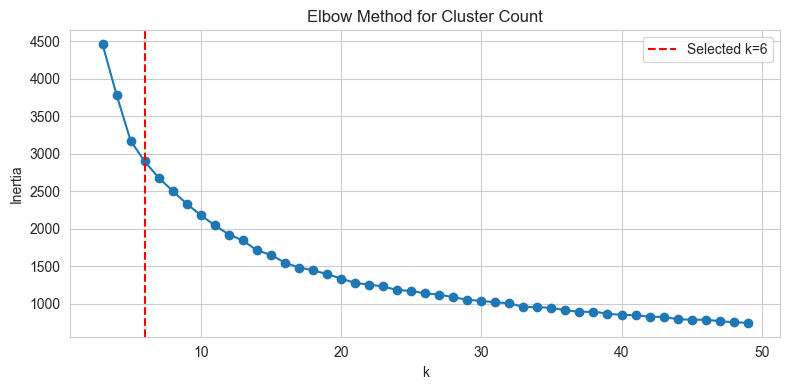


Selected k=6 (elbow method, floor=3)

Cluster composition:
  Cluster 0: 177 regions (DE:160, PL:17)
  Cluster 1: 145 regions (DE:120, FR:25)
  Cluster 2: 76 regions (DE:68, FR:8)
  Cluster 3: 3 regions (FR:3)
  Cluster 4: 40 regions (FR:40)
  Cluster 5: 74 regions (DE:53, FR:21)


In [13]:
# ============================================================
# Agro-climatic clustering of regions
#
# 1. Compute long-term climate profile per region (mean of key
#    variables over training period)
# 2. Standardise profiles
# 3. Apply k-means clustering
# 4. Aggregate features within each cluster (production-weighted)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Compute climate profiles ---
PROFILE_VARS = ['meteo_tavg', 'meteo_tmax', 'meteo_tmin', 'meteo_prec',
                'meteo_vpd', 'ndvi_ndvi', 'soil_moisture_ssm']

profiles = {}
for adm_id, df in all_region_dfs.items():
    available = [v for v in PROFILE_VARS if v in df.columns]
    if not available:
        continue
    # Use training period only (avoid test leakage)
    train_df = df[df['date'].dt.year < 2017]
    if len(train_df) < 100:
        continue
    profile = {}
    for v in available:
        vals = train_df[v].dropna()
        if len(vals) > 0:
            profile[f'{v}_mean'] = vals.mean()
            profile[f'{v}_std'] = vals.std()
    if profile:
        profiles[adm_id] = profile

profile_df = pd.DataFrame(profiles).T
profile_df = profile_df.fillna(profile_df.median())
print(f"Climate profiles computed for {len(profile_df)} regions")
print(f"Profile features: {list(profile_df.columns)}")

# --- Step 2: Standardise and cluster ---
scaler_profile = StandardScaler()
X_profiles = scaler_profile.fit_transform(profile_df.values)

# Elbow method: plot inertia (within-cluster sum of squares) vs k.
# Pick the k where the marginal decrease in inertia slows down.
# More robust than silhouette for our purpose since we WANT granularity.

k_range = range(3, 50)
inertias = []
for k in k_range:
    if k >= len(profile_df):
        break
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_profiles)
    inertias.append((k, km.inertia_))
    print(f"  k={k}: inertia={km.inertia_:.1f}")

inertia_df = pd.DataFrame(inertias, columns=['k', 'inertia'])

# Automated elbow detection: largest drop in second derivative
diffs = np.diff(inertia_df['inertia'].values)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2  # +2 because of double diff offset
best_k = inertia_df.iloc[elbow_idx]['k']

# But enforce a floor
best_k = int(max(best_k, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(inertia_df['k'], inertia_df['inertia'], 'o-')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Cluster Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSelected k={best_k} (elbow method, floor=3)")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_profiles)
profile_df['cluster'] = cluster_labels

# Map region -> cluster
region_cluster = profile_df['cluster'].to_dict()

# Report cluster composition
print(f"\nCluster composition:")
for c in sorted(profile_df['cluster'].unique()):
    members = profile_df[profile_df['cluster'] == c].index.tolist()
    countries = {}
    for r in members:
        cc = r[:2]
        countries[cc] = countries.get(cc, 0) + 1
    country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
    print(f"  Cluster {c}: {len(members)} regions ({country_str})")

In [14]:
# ============================================================
# Aggregate features within each cluster (production-weighted)
#
# For each cluster, at each date:
#   weighted_mean = SUM(w_r * feature_r) / SUM(w_r)
#
# This is the same aggregation Paudel et al. (2022) use at
# the country level, but applied to agro-climatic clusters.
# ============================================================

def aggregate_cluster_features(cluster_id, region_dfs, region_cluster, ref_year=2016):
    """
    Production-weighted aggregation of features within a cluster.
    Returns a single daily DataFrame.
    """
    members = [r for r, c in region_cluster.items() if c == cluster_id and r in region_dfs]
    if not members:
        return None

    # Get all dates from all members
    all_dates = set()
    for adm_id in members:
        all_dates.update(region_dfs[adm_id]['date'].values)
    all_dates = sorted(all_dates)

    # For each date, compute weighted average
    rows = []
    # Pre-compute weights
    weights = {r: get_production_weight(r, ref_year) for r in members}
    total_w = sum(weights.values())
    if total_w == 0:
        weights = {r: 1.0 for r in members}
        total_w = len(members)

    # Get common feature columns
    feature_cols = None
    for adm_id in members:
        cols = set(c for c in region_dfs[adm_id].columns if c != 'date')
        if feature_cols is None:
            feature_cols = cols
        else:
            feature_cols = feature_cols & cols
    feature_cols = sorted(feature_cols)

    # Build indexed DataFrames for fast lookup
    indexed = {}
    for adm_id in members:
        df = region_dfs[adm_id].set_index('date')[feature_cols]
        indexed[adm_id] = df

    # Align all to common date range and compute weighted average
    date_range = pd.date_range(min(all_dates), max(all_dates), freq='D')
    result = pd.DataFrame(index=date_range, columns=feature_cols, dtype=float)
    result[:] = 0.0

    for adm_id in members:
        w = weights[adm_id] / total_w
        reindexed = indexed[adm_id].reindex(date_range).ffill().fillna(0)
        result += reindexed * w

    result = result.reset_index().rename(columns={'index': 'date'})
    return result, members


# Build cluster aggregates
print("Aggregating features within clusters...\n")
cluster_dfs = {}  # {cluster_id: DataFrame}
cluster_members = {}  # {cluster_id: [region_ids]}

for c in sorted(profile_df['cluster'].unique()):
    result = aggregate_cluster_features(c, all_region_dfs, region_cluster)
    if result is not None:
        cluster_df, members = result
        cluster_dfs[c] = cluster_df
        cluster_members[c] = members
        n_feats = len([col for col in cluster_df.columns if col != 'date'])
        print(f"  Cluster {c}: {len(members)} regions -> {cluster_df.shape[0]} days, "
              f"{n_feats} features")

print(f"\n{len(cluster_dfs)} cluster aggregates built")

Aggregating features within clusters...

  Cluster 0: 177 regions -> 8400 days, 76 features
  Cluster 1: 145 regions -> 8400 days, 68 features
  Cluster 2: 76 regions -> 8400 days, 76 features
  Cluster 3: 3 regions -> 8400 days, 76 features
  Cluster 4: 40 regions -> 8400 days, 76 features
  Cluster 5: 74 regions -> 8400 days, 76 features

6 cluster aggregates built


In [15]:
# ============================================================
# Merge each cluster's aggregated features with futures
# ============================================================

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

cluster_model_data = {}

for c, cdf in cluster_dfs.items():
    ag_sorted = cdf.sort_values('date')

    merged = pd.merge_asof(
        futures_sorted,
        ag_sorted,
        left_on='Date',
        right_on='date',
        direction='backward'
    )
    merged = merged.drop(columns=['date'], errors='ignore')

    ag_cols = [col for col in cdf.columns if col != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)

    cluster_model_data[c] = {
        'df': merged.dropna(subset=['Fwd_Return'] + price_feature_cols).copy(),
        'ag_cols': ag_cols,
        'all_cols': price_feature_cols + ag_cols,
    }
    print(f"Cluster {c}: {merged.shape[0]} rows, "
          f"{len(ag_cols)} ag features, "
          f"{len(price_feature_cols)} price features")

Cluster 0: 5364 rows, 76 ag features, 3 price features
Cluster 1: 5364 rows, 68 ag features, 3 price features
Cluster 2: 5364 rows, 76 ag features, 3 price features
Cluster 3: 5364 rows, 76 ag features, 3 price features
Cluster 4: 5364 rows, 76 ag features, 3 price features
Cluster 5: 5364 rows, 76 ag features, 3 price features


---
## 5. Systematic Cross-Validation and Feature Selection for Return Prediction

### 5.1 The Question
All models produce negative out-of-sample R-squared. Is it because (a) signal is drowned in noise from too many features, or (b) there is genuinely no signal? We sweep feature count from 3 to all and plot R-squared versus k. A peak at low k means noise dilution. A flat curve means no signal.

### 5.2 Protocol
Purged TimeSeriesSplit (10 folds, 30-day gap). Feature selection via MI is done independently inside each fold's training set — test set never influences selection. CY-Bench agricultural features only, no market data.

In [ ]:
# Setup
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Ridge, Lasso, LassoCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

c0_key = list(cluster_model_data.keys())[0]
c0_data = cluster_model_data[c0_key]
cv_df = c0_data['df'].copy().sort_values('Date').reset_index(drop=True)
all_feat_cols = c0_data['all_cols']
ag_only_cols = c0_data['ag_cols']
n_feats = len(all_feat_cols)
price_set = set(price_feature_cols)

wide_df = futures.dropna(subset=['Fwd_Return']+price_feature_cols).copy().sort_values('Date')
for c_id in sorted(cluster_dfs.keys()):
    cdf = cluster_dfs[c_id].copy()
    cdf = cdf.rename(columns={x: f'C{c_id}_{x}' for x in cdf.columns if x != 'date'})
    wide_df = pd.merge_asof(wide_df.sort_values('Date'), cdf.sort_values('date'),
        left_on='Date', right_on='date', direction='backward').drop(columns=['date'], errors='ignore')
wide_df = wide_df.ffill().fillna(0).dropna(subset=['Fwd_Return']+price_feature_cols).reset_index(drop=True)
wide_ag_cols = [c for c in wide_df.columns if c not in ['Date','Price','Open','High','Low','Volume','Fwd_Return','year']+price_feature_cols]
wide_all_cols = price_feature_cols + wide_ag_cols

tscv = TimeSeriesSplit(n_splits=10, gap=30)
X_cv = cv_df[all_feat_cols].values
print(f'Single cluster: {len(cv_df)} obs, {n_feats} features ({len(ag_only_cols)} AG + {len(price_feature_cols)} price)')
print(f'Wide matrix: {len(wide_df)} obs, {len(wide_all_cols)} features')
print(f'CV: {tscv.n_splits} folds, gap={tscv.gap}')
for fi, (tr, te) in enumerate(tscv.split(X_cv)):
    if fi<2 or fi>=tscv.n_splits-2:
        print(f'  Fold {fi+1}: train={len(tr)} test={len(te)} ({cv_df.iloc[te[0]]["Date"].strftime("%Y-%m")} to {cv_df.iloc[te[-1]]["Date"].strftime("%Y-%m")})')
    elif fi==2: print('  ...')

In [ ]:
# Step 1: Per-fold MI ranking
rank_matrix = np.zeros((tscv.n_splits, n_feats))
print('Per-fold MI ranking...\n')
for fi, (tr_idx, te_idx) in enumerate(tscv.split(X_cv)):
    sc = StandardScaler()
    X_tr = sc.fit_transform(cv_df.iloc[tr_idx][all_feat_cols].values)
    y_tr = cv_df.iloc[tr_idx]['Fwd_Return'].values
    mi = mutual_info_regression(X_tr, y_tr, random_state=42, n_jobs=-1)
    ranks = np.argsort(-mi); rank_pos = np.empty_like(ranks); rank_pos[ranks] = np.arange(len(ranks))
    rank_matrix[fi] = rank_pos

avg_rank = rank_matrix.mean(axis=0); rank_std = rank_matrix.std(axis=0)
global_ranking = np.argsort(avg_rank)
print(f'{"Rank":>4s}  {"Feature":45s} {"AvgRank":>8s} {"Std":>6s} {"Type":>5s}')
print('-'*72)
for i in range(25):
    idx = global_ranking[i]; ftype = 'PRICE' if all_feat_cols[idx] in price_set else 'AG'
    print(f'{i+1:4d}  {all_feat_cols[idx]:45s} {avg_rank[idx]:8.1f} {rank_std[idx]:6.1f} {ftype:>5s}')
n_price_top10 = sum(1 for i in range(10) if all_feat_cols[global_ranking[i]] in price_set)
print(f'\nTop 10: {n_price_top10} price, {10-n_price_top10} agricultural')

In [ ]:
# Step 2: Feature count sweep — single cluster
K_VALUES = [3, 5, 10, 20, 50, n_feats]
MODELS = {'Ridge(a=1)':(Ridge,{'alpha':1.0}), 'Ridge(a=100)':(Ridge,{'alpha':100.0}),
          'Lasso':(Lasso,{'alpha':0.001,'max_iter':10000}),
          'ExtraTrees':(ExtraTreesRegressor,{'n_estimators':200,'max_depth':5,'min_samples_leaf':20,'max_features':'sqrt','random_state':42,'n_jobs':-1})}
results = {mn:{'k':[],'r2_test':[],'r2_train':[],'dir':[]} for mn in MODELS}

print(f'Feature count sweep (single cluster, 10-fold purged CV)\n')
hdr = f'{"k":>5s}'; [hdr := hdr + f'  {mn:>15s}' for mn in MODELS]; print(hdr); print('-'*(5+17*len(MODELS)))

for k in K_VALUES:
    row = f'{k:5d}'
    for mn, (mc, mk) in MODELS.items():
        r2s, r2s_tr, ds = [], [], []
        for tr_idx, te_idx in tscv.split(X_cv):
            sc = StandardScaler(); X_tr = sc.fit_transform(cv_df.iloc[tr_idx][all_feat_cols].values)
            X_te = sc.transform(cv_df.iloc[te_idx][all_feat_cols].values)
            y_tr = cv_df.iloc[tr_idx]['Fwd_Return'].values; y_te = cv_df.iloc[te_idx]['Fwd_Return'].values
            if k < n_feats:
                mi = mutual_info_regression(X_tr, y_tr, random_state=42, n_jobs=-1); sel = np.argsort(-mi)[:k]
            else: sel = np.arange(n_feats)
            m = mc(**mk); m.fit(X_tr[:,sel], y_tr)
            r2s.append(r2_score(y_te, m.predict(X_te[:,sel]))); r2s_tr.append(r2_score(y_tr, m.predict(X_tr[:,sel])))
            ds.append(np.mean(np.sign(m.predict(X_te[:,sel]))==np.sign(y_te)))
        r2 = np.mean(r2s); results[mn]['k'].append(k); results[mn]['r2_test'].append(r2)
        results[mn]['r2_train'].append(np.mean(r2s_tr)); results[mn]['dir'].append(np.mean(ds))
        row += f'  {r2:+15.4f}'
    print(row)

In [ ]:
# Step 2b: Wide matrix sweep
n_wide = len(wide_all_cols); K_WIDE = [k for k in [3,5,10,20,50,100,200,n_wide] if k<=n_wide]
X_wide = wide_df[wide_all_cols].values; tscv_w = TimeSeriesSplit(n_splits=10, gap=30)
rw = {mn:{'k':[],'r2':[]} for mn in ['Ridge(a=1)','Ridge(a=100)','Lasso']}
print(f'\nWide matrix sweep ({n_wide} features)\n')
print(f'{"k":>5s}  {"Ridge(a=1)":>12s} {"Ridge(a=100)":>12s} {"Lasso":>12s}'); print('-'*45)
for k in K_WIDE:
    row = f'{k:5d}'
    for mn,(mc,mk) in [('Ridge(a=1)',(Ridge,{'alpha':1.0})),('Ridge(a=100)',(Ridge,{'alpha':100.0})),('Lasso',(Lasso,{'alpha':0.001,'max_iter':10000}))]:
        r2s = []
        for tr_idx, te_idx in tscv_w.split(X_wide):
            sc = StandardScaler(); X_tr=sc.fit_transform(wide_df.iloc[tr_idx][wide_all_cols].values)
            X_te=sc.transform(wide_df.iloc[te_idx][wide_all_cols].values)
            y_tr=wide_df.iloc[tr_idx]['Fwd_Return'].values; y_te=wide_df.iloc[te_idx]['Fwd_Return'].values
            if k<n_wide: mi=mutual_info_regression(X_tr,y_tr,random_state=42,n_jobs=-1); sel=np.argsort(-mi)[:k]
            else: sel=np.arange(n_wide)
            m=mc(**mk); m.fit(X_tr[:,sel],y_tr); r2s.append(r2_score(y_te, m.predict(X_te[:,sel])))
        r2=np.mean(r2s); rw[mn]['k'].append(k); rw[mn]['r2'].append(r2); row += f'  {r2:+12.4f}'
    print(row)

In [ ]:
# Step 3: Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'Ridge(a=1)':'blue','Ridge(a=100)':'cyan','Lasso':'green','ExtraTrees':'red'}

ax = axes[0,0]
for mn in results: ax.plot(results[mn]['k'], results[mn]['r2_test'], 'o-', color=colors[mn], lw=2, label=mn)
ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_xlabel('k'); ax.set_ylabel('Test R²')
ax.set_title('Single Cluster: Test R² vs k'); ax.set_xscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0,1]
for mn in results: ax.plot(results[mn]['k'], results[mn]['r2_train'], 'o-', color=colors[mn], lw=2, label=mn)
ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_xlabel('k'); ax.set_ylabel('Train R²')
ax.set_title('Single Cluster: Train R²'); ax.set_xscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,0]
for mn in results:
    gaps = [tr-te for tr,te in zip(results[mn]['r2_train'], results[mn]['r2_test'])]
    ax.plot(results[mn]['k'], gaps, 'o-', color=colors[mn], lw=2, label=mn)
ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_xlabel('k'); ax.set_ylabel('Gap')
ax.set_title('Overfitting Gap vs k'); ax.set_xscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,1]
for mn in rw: ax.plot(rw[mn]['k'], rw[mn]['r2'], 'o-', color=colors[mn], lw=2, label=f'{mn} (wide)')
ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_xlabel('k'); ax.set_ylabel('Test R²')
ax.set_title(f'Wide ({n_wide} features): Test R² vs k'); ax.set_xscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Does Reducing CY-Bench Features Help?', fontsize=13, y=1.01); plt.tight_layout(); plt.show()

In [ ]:
# Step 4: Stability selection
selection_counts = np.zeros(n_feats); n_ok = 0; alphas = []
print('Stability selection (LassoCV)\n')
for fi, (tr_idx, te_idx) in enumerate(tscv.split(X_cv)):
    sc = StandardScaler(); X_tr = sc.fit_transform(cv_df.iloc[tr_idx][all_feat_cols].values)
    y_tr = cv_df.iloc[tr_idx]['Fwd_Return'].values
    try:
        lasso = LassoCV(cv=3, max_iter=10000, random_state=42, n_jobs=-1); lasso.fit(X_tr, y_tr)
        nonzero = np.abs(lasso.coef_) > 1e-8; selection_counts += nonzero.astype(int); n_ok += 1
        alphas.append(lasso.alpha_)
        print(f'  Fold {fi+1:2d}: alpha={lasso.alpha_:.6f} selected={nonzero.sum()}/{n_feats}')
    except Exception as e: print(f'  Fold {fi+1}: FAILED ({e})')

stability = selection_counts / max(n_ok, 1)
print(f'\nStable (>=50% folds): {(stability>=0.5).sum()}, Never selected: {(stability==0).sum()}')
stable_names = []
print(f'\nTop 15 by stability:')
for rank, i in enumerate(np.argsort(-stability)[:15]):
    fn = all_feat_cols[i]; ftype = 'PRICE' if fn in price_set else 'AG'
    if stability[i] >= 0.5: stable_names.append((fn, ftype))
    print(f'  {rank+1:2d}. [{ftype:5s}] {fn:45s} {stability[i]:.2f}')

In [ ]:
# Step 5: Price-only baseline under same CV
print('Price-only baseline\n')
for mn, (mc, mk) in MODELS.items():
    r2s = []
    for tr_idx, te_idx in tscv.split(X_cv):
        sc = StandardScaler(); X_tr=sc.fit_transform(cv_df.iloc[tr_idx][price_feature_cols].values)
        X_te=sc.transform(cv_df.iloc[te_idx][price_feature_cols].values)
        y_tr=cv_df.iloc[tr_idx]['Fwd_Return'].values; y_te=cv_df.iloc[te_idx]['Fwd_Return'].values
        m=mc(**mk); m.fit(X_tr,y_tr); r2s.append(r2_score(y_te, m.predict(X_te)))
    print(f'  {mn:15s} R2(price-only)={np.mean(r2s):+.4f}')

print(f'\nBest k per model:')
for mn in MODELS:
    bi = np.argmax(results[mn]['r2_test']); print(f'  {mn:15s} best R2={results[mn]["r2_test"][bi]:+.4f} at k={results[mn]["k"][bi]}')

print(f'\n{"="*70}')
print('CONCLUSION')
print('='*70)
all_best = [max(results[mn]['r2_test']) for mn in MODELS]
best = max(all_best)
n_price_stable = sum(1 for _,t in stable_names if t=='PRICE')
n_ag_stable = sum(1 for _,t in stable_names if t=='AG')
print(f'  Best R² at any k: {best:+.4f}')
print(f'  Stable features: {n_price_stable} price, {n_ag_stable} agricultural')
if best < 0: print(f'  Negative R² at ALL feature counts → no signal at any dimensionality.')
if n_ag_stable == 0: print(f'  Zero stable AG features → CY-Bench adds no temporally persistent signal.')